In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import statsmodels.api as sm

sns.set_style("whitegrid")
sns.set_context("poster")
import warnings
warnings.filterwarnings("ignore")
#

In [12]:
column_names = [
    "color",
    "fixed_acidity",
    "volatile_acidity",
    "residual_sugar",
    "total_sulfur_dioxide",
    "pH",
    "sulphates",
    "chlorides",
    "alcohol",
    "quality"
]

df = pd.read_csv("/content/winequality-white.csv", sep=';')


rename_map = {
    'fixed acidity': 'fixed_acidity',
    'volatile acidity': 'volatile_acidity',
    'citric acid': 'citric_acid',
    'residual sugar': 'residual_sugar',
    'chlorides': 'chlorides',
    'free sulfur dioxide': 'free_sulfur_dioxide',
    'total sulfur dioxide': 'total_sulfur_dioxide',
    'density': 'density',
    'pH': 'pH',
    'sulphates': 'sulphates',
    'alcohol': 'alcohol',
    'quality': 'quality'
}
df = df.rename(columns=rename_map)

columns_to_keep_from_csv = [
    "fixed_acidity",
    "volatile_acidity",
    "residual_sugar",
     "citric_acid",
    "total_sulfur_dioxide",
    "free_sulfur_dioxide",
    "density",
    "pH",
    "sulphates",
    "chlorides",
    "alcohol",
    "quality"
]
df = df[columns_to_keep_from_csv]

df["color"] = df["quality"] + 1.5

df = df[column_names]

df.head(2)

,color,fixed_acidity,volatile_acidity,residual_sugar,total_sulfur_dioxide,pH,sulphates,chlorides,alcohol,quality
0,7.5,7.0,0.27,20.7,170.0,3.0,0.45,0.045,8.8,6
1,7.5,6.3,0.30,1.6,132.0,3.3,0.49,0.049,9.5,6


In [13]:
print("Veri Seti Boyutu:",df.shape)
df.info()

Veri Seti Boyutu: (4898, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   color                 4898 non-null   float64
 1   fixed_acidity         4898 non-null   float64
 2   volatile_acidity      4898 non-null   float64
 3   residual_sugar        4898 non-null   float64
 4   total_sulfur_dioxide  4898 non-null   float64
 5   pH                    4898 non-null   float64
 6   sulphates             4898 non-null   float64
 7   chlorides             4898 non-null   float64
 8   alcohol               4898 non-null   float64
 9   quality               4898 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 382.8 KB


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
color,4898.0,7.377909,0.885639,4.500,6.500,7.500,7.50,10.500
fixed_acidity,4898.0,6.854788,0.843868,3.800,6.300,6.800,7.30,14.200
volatile_acidity,4898.0,0.278241,0.100795,0.080,0.210,0.260,0.32,1.100
residual_sugar,4898.0,6.391415,5.072058,0.600,1.700,5.200,9.90,65.800
total_sulfur_dioxide,4898.0,138.360657,42.498065,9.000,108.000,134.000,167.00,440.000
pH,4898.0,3.188267,0.151001,2.720,3.090,3.180,3.28,3.820
sulphates,4898.0,0.489847,0.114126,0.220,0.410,0.470,0.55,1.080
chlorides,4898.0,0.045772,0.021848,0.009,0.036,0.043,0.05,0.346
alcohol,4898.0,10.514267,1.230621,8.000,9.500,10.400,11.40,14.200
quality,4898.0,5.877909,0.885639,3.000,5.000,6.000,6.00,9.000


In [17]:
df["color"].value_counts()

,count
color,
7.5,2198
6.5,1457
8.5,880
9.5,175
5.5,163
4.5,20
10.5,5


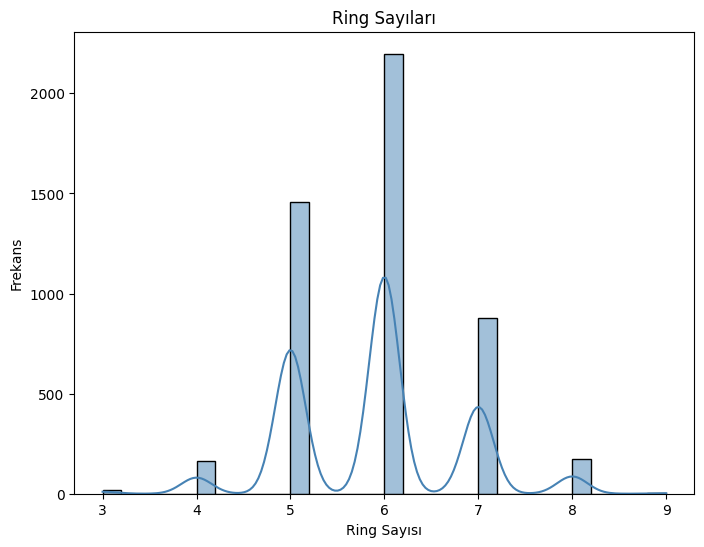

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.histplot(df["quality"],bins=30,kde= True, color ="steelblue")

plt.title("Ring Sayıları")
plt.xlabel("Ring Sayısı")
plt.ylabel("Frekans")

plt.show()

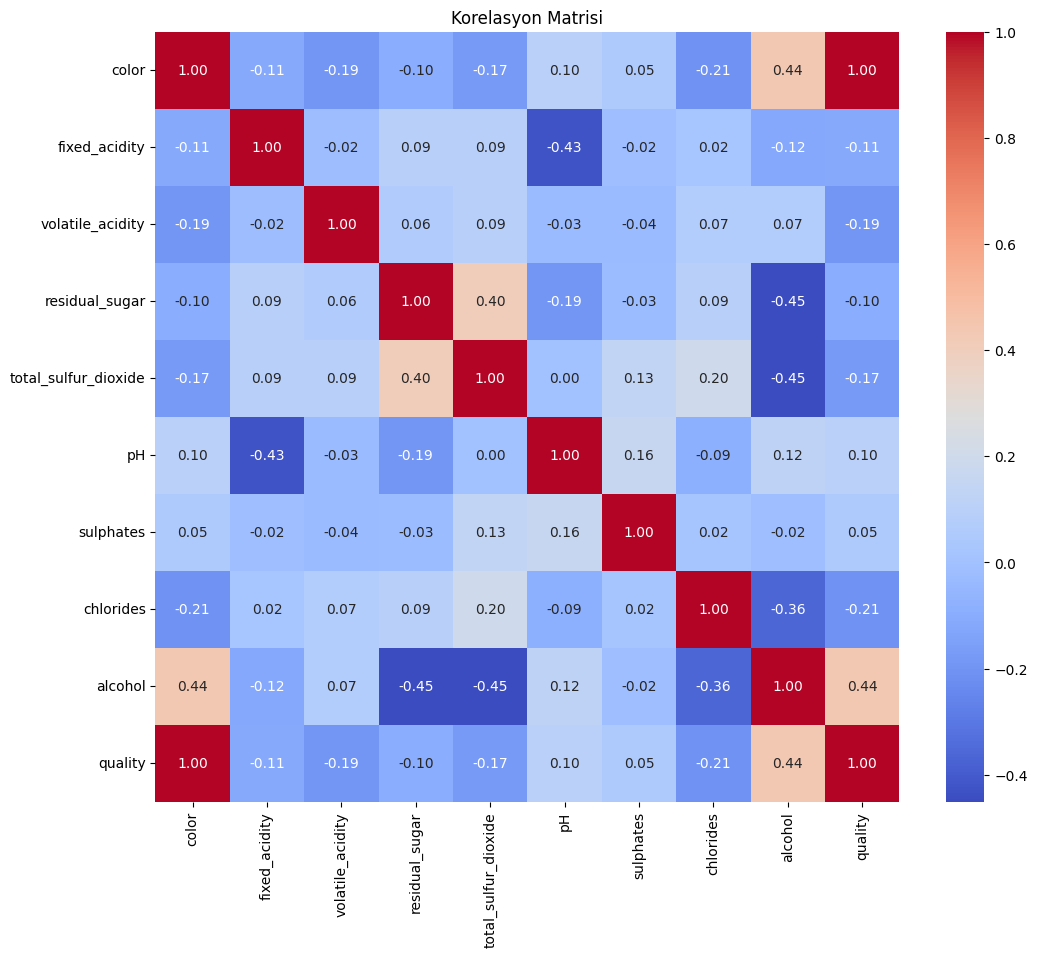

In [20]:
numeric_cols = df.select_dtypes(include=[np.number]) # numeric_cols = df.drop(columns=["X"])
corr_matrix = numeric_cols.corr()
plt.figure(figsize=(12, 10
                    ))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasyon Matrisi")
plt.show()

In [25]:
df_encoded = pd.get_dummies(df, columns=["color"],drop_first=True)

In [26]:
df_encoded

,fixed_acidity,volatile_acidity,residual_sugar,total_sulfur_dioxide,pH,sulphates,chlorides,alcohol,quality,color_5.5,color_6.5,color_7.5,color_8.5,color_9.5,color_10.5
0,7.0,0.27,20.7,170.0,3.00,0.45,0.045,8.8,6,False,False,True,False,False,False
1,6.3,0.30,1.6,132.0,3.30,0.49,0.049,9.5,6,False,False,True,False,False,False
2,8.1,0.28,6.9,97.0,3.26,0.44,0.050,10.1,6,False,False,True,False,False,False
3,7.2,0.23,8.5,186.0,3.19,0.40,0.058,9.9,6,False,False,True,False,False,False
4,7.2,0.23,8.5,186.0,3.19,0.40,0.058,9.9,6,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,1.6,92.0,3.27,0.50,0.039,11.2,6,False,False,True,False,False,False
4894,6.6,0.32,8.0,168.0,3.15,0.46,0.047,9.6,5,False,True,False,False,False,False
4895,6.5,0.24,1.2,111.0,2.99,0.46,0.041,9.4,6,False,False,True,False,False,False
4896,5.5,0.29,1.1,110.0,3.34,0.38,0.022,12.8,7,False,False,False,True,False,False


In [29]:
X = df_encoded.drop(columns=["quality", "alcohol"])
y = df_encoded["quality"]

In [30]:
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
model=LinearRegression()
model.fit(X_train,y_train)
model_pred =model.predict(X_test)

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

r2_multi = r2_score(y_test,model_pred)
print("R2 Değeri:",r2_multi)
mae_multi = mean_absolute_error(y_test,model_pred)
print("MAE Değeri:",mae_multi)
mse_multi = mean_squared_error(y_test,model_pred)
print("MSE Değeri:",mse_multi)

R2 Değeri: 1.0
MAE Değeri: 2.8272169186270822e-15
MSE Değeri: 1.502639156427238e-29


In [35]:
import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train,X_train_sm).fit()
model_sm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 7.207e+30
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:57:38   Log-Likelihood:             1.2293e+05
No. Observations:                3918   AIC:                        -2.458e+05
Df Residuals:                    3904   BIC:                        -2.457e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    3.0000   3.18e-15   9.44e+14      0.000       3.000       3.000
fixed_acidity        -2.354e-15   1.22e-16    -19.229      0.000   -2.59e-15   -2.11e-15
volatile_acidity      5.328e-16   9.44e-16      0.564      0.573   -1.32e-15    2.38e-15
residual_sugar        1.465e-16   2.01e-17      7.294      0.000    1.07e-16    1.86e-16
total_sulfur_dioxide  9.788e-17   2.51e-18     38.951      0.000    9.29e-17    1.03e-16
pH                    1.062e-15   7.06e-16      1.504      0.133   -3.22e-16    2.45e-15
sulphates            -3.279e-15   8.29e-16     -3.954      0.000    -4.9e-15   -1.65e-15
chlorides            -1.915e-15   4.38e-15     -0.437      0.662   -1.05e-14    6.67e-15
color_5.5                1.0000   1.56e-15    6.4e+14      0.000       1.000       1.000
color_6.5                2.0000    1.5e-15   1.34e+15      0.000       2.000       2.000
color_7.5                3.0000    1.5e-15   2.01e+15      0.000       3.000       3.000
color_8.5                4.0000   1.51e-15   2.66e+15      0.000       4.000       4.000
color_9.5                5.0000   1.57e-15   3.19e+15      0.000       5.000       5.000
color_10.5               6.0000   2.97e-15   2.02e+15      0.000       6.000       6.000
==============================================================================
Omnibus:                        1.076   Durbin-Watson:                   1.483
Prob(Omnibus):                  0.584   Jarque-Bera (JB):                1.094
Skew:                           0.040   Prob(JB):                        0.579
Kurtosis:                       2.983   Cond. No.                     7.16e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.16e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Text(0, 0.5, 'Tahmin Edilen Değerler')

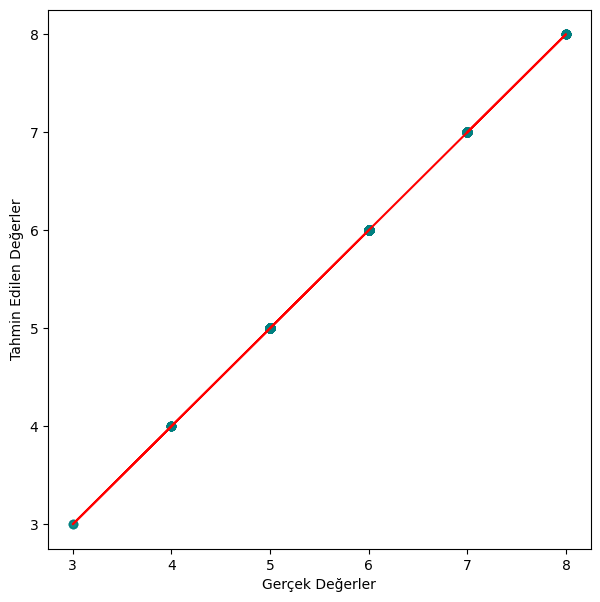

In [36]:
plt.figure(figsize=(7,7))
plt.scatter(y_test,model_pred ,alpha=0.4,color="teal")
plt.plot(y_test,y_test,"r")
plt.xlabel("Gerçek Değerler")
plt.ylabel("Tahmin Edilen Değerler")

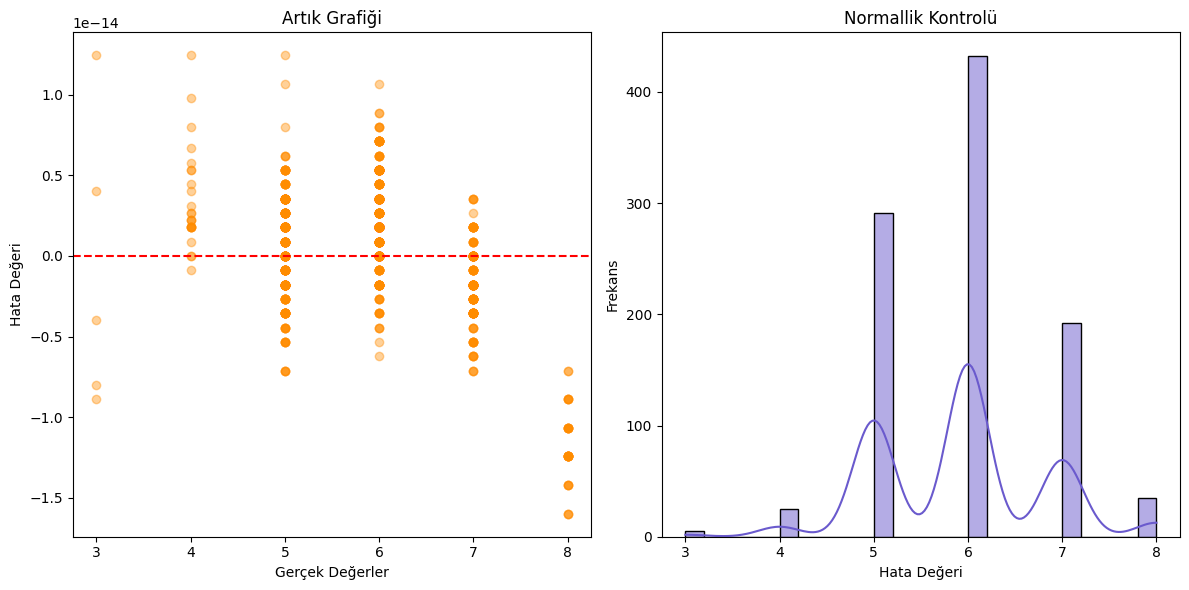

In [37]:
residual =y_test-model_pred
fig, axes = plt.subplots(1,2,figsize=(12,6))
axes[0].scatter(model_pred,residual,alpha=0.4,color="darkorange")
axes[0].axhline(y=0,color="red",linestyle="--")
axes[0].set_xlabel("Gerçek Değerler")
axes[0].set_ylabel("Hata Değeri")
axes[0].set_title("Artık Grafiği")
sns.histplot(y_test,kde=True,ax=axes[1],color="slateblue")
axes[1].set_title("Gerçek Değerler")
axes[1].set_title("Normallik Kontrolü")
axes[1].set_xlabel("Hata Değeri")
axes[1].set_ylabel("Frekans")

plt.tight_layout()
plt.show()


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


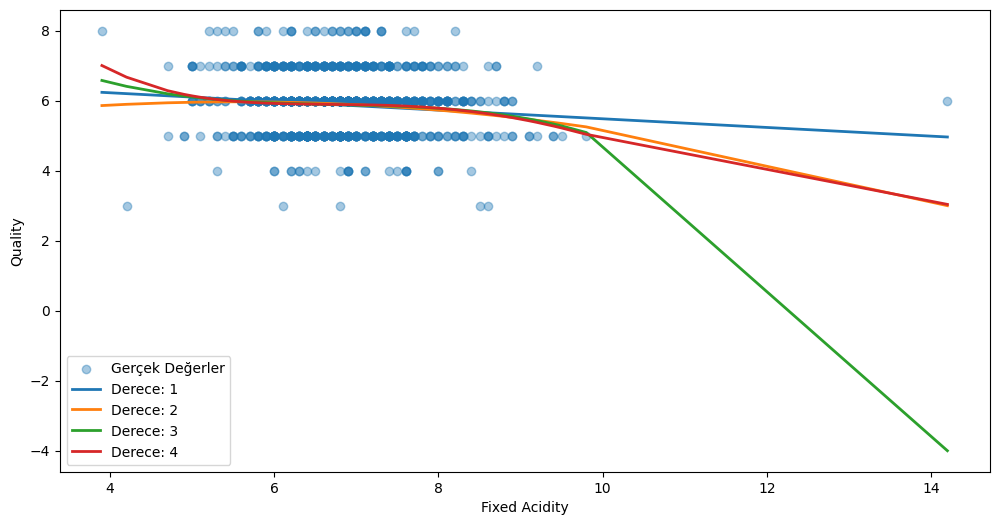

,r2,Rmse
Derece,,
1,0.007476,0.876746
2,-0.002151,0.880987
3,-0.120265,0.931459
4,-0.000909,0.880441


In [39]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

degrees =[1,2,3,4]

poly_results= {}

plt.figure(figsize=(12,6))
X_one_train =X_train[['fixed_acidity']]
X_one_test =X_test[['fixed_acidity']]
sort_idx =X_one_test['fixed_acidity'].values.argsort()
x_sorted =X_one_test['fixed_acidity'].values[sort_idx]
plt.scatter(X_one_test['fixed_acidity'],y_test,alpha=0.4,color="#1f77b4",label="Gerçek Değerler")
for degree in degrees:
    model_poly = make_pipeline(PolynomialFeatures(degree),LinearRegression())
    model_poly.fit(X_one_train,y_train)
    poly_pred = model_poly.predict(X_one_test)
    poly_results[degree]={
        "r2": r2_score(y_test,poly_pred),
        "Rmse" : np.sqrt(mean_squared_error(y_test,poly_pred))
}
    y_line = model_poly.predict(x_sorted.reshape(-1,1))
    plt.plot(x_sorted,y_line,linewidth=2,label=f"Derece: {degree}")
plt.xlabel("Fixed Acidity")
plt.ylabel("Quality")
plt.legend()
plt.show()

pd.DataFrame(poly_results).T.rename_axis("Derece")